In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score


In [ ]:
posts_data = pd.read_csv("../data/fb_data_with_predictions.csv")
highlevel_unions = pd.read_csv("../data/mapping_fb_unions.csv")
highlevel_unions = highlevel_unions.dropna(subset=["account_match"])
highlevel_unions_handles = highlevel_unions[["union", "account_match"]]
highlevel_unions_handles.columns = ["main_union", "handle"]

posts_data = posts_data.merge(highlevel_unions_handles, how="left", left_on="surface.username", right_on="handle")

emotion_predictions = pd.read_csv("../data/posts_emotion_predictions_mean-pool.csv")

merged = posts_data.merge(emotion_predictions, on="id", how="inner")

In [108]:
frame_cols = ["diagnostic", "prognostic", "motivational",
              "community", "engagement"]

emotion_cols = ["anger", "disgust", "fear", "joy",
                "neutral", "sadness", "surprise"]

# Correlations

In [113]:
corr_matrix = merged[emotion_cols + frame_cols].corr()[frame_cols].T[emotion_cols]


In [114]:
corr_matrix

,anger,disgust,fear,joy,neutral,sadness,surprise
diagnostic,0.344639,0.197029,0.159090,-0.330757,-0.109746,0.044888,-0.220586
prognostic,0.326397,-0.003029,0.175079,-0.227098,-0.112635,-0.039044,-0.216430
motivational,0.076731,-0.072369,0.163400,-0.128591,-0.042068,-0.036408,-0.091781
community,-0.033871,-0.135198,0.033566,0.335010,-0.237681,0.021174,-0.039980
engagement,-0.193924,-0.101143,-0.066953,0.094796,0.122585,-0.052080,0.115884


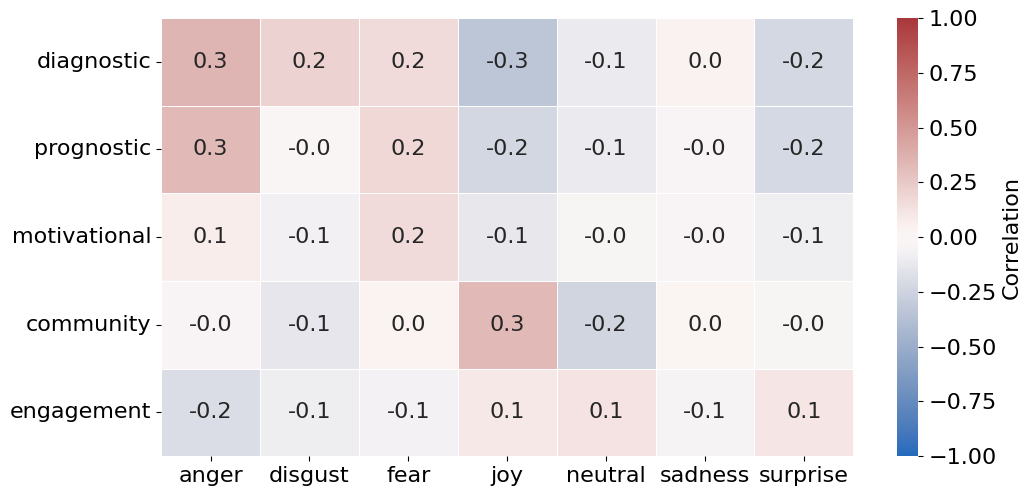

In [ ]:
plt.figure(figsize=(10, 5))

ax = sns.heatmap(
    corr_matrix,
    annot=True,          # write values in cells
    fmt=".1f",           # 2 decimal places
    cmap="vlag",       # diverging colormap (nice for probabilities)
    vmin=-1,
    vmax=1,
    center = 0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'},
    # annotation font size
    annot_kws={"size": 16}
)
# get the colorbar and relabel ticks
colorbar = ax.collections[0].colorbar
# fontsize of colorbar ticks
colorbar.ax.tick_params(labelsize=16)
ax.figure.axes[-1].yaxis.label.set_size(16)

#plt.title("Emotion Distribution by Frame", fontsize=14)
#plt.xlabel("Emotion")
#plt.ylabel("Frame")
plt.tight_layout()
# increase font size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16, rotation=0)
#plt.show()
# save as svg
plt.savefig("../data/plots/emotion_by_frame_heatmap_corr.svg")